# Relational Link Prediction

This notebook demonstrates relational link prediction on knowledge graphs
using the DistMult decoder with proper relation-type modelling.

Datasets:
- **FB15k-237** — Freebase knowledge graph (14.5 K entities, 237 relations).
- **WordNet18-RR** — WordNet lexical database (40.9 K entities, 11 relations).

## FB15k-237 with relational decoder

In [1]:
from graphnetz.datasets.knowledge import fb15k_237

ds = fb15k_237('data/knowledge')
data = ds[0]
print(f"Entities: {data.num_nodes:,}, Relations: {ds.num_relations}")
print(f"Train triples: {data.train_edge_index.size(1):,}")
print(f"Val triples: {data.valid_edge_index.size(1):,}")
print(f"Test triples: {data.test_edge_index.size(1):,}")

/Users/holisticai008/Documents/repos/research/graphnet/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Processing...


Entities: 14,541, Relations: 474
Train triples: 272,115
Val triples: 17,535
Test triples: 20,466


Done!


### Manual training with relational decoder

In [2]:
import torch
from torch_geometric.data import Data
from graphnetz import GCN
from graphnetz.models._adapters import RelationalLinkPredWrapper
from graphnetz.training import train_relational_link_prediction

# Build encoder + relational decoder
encoder = GCN(data.num_features, 128, 128)
model = RelationalLinkPredWrapper(encoder, 128, ds.num_relations)

# Create train/val/test splits
train_data = Data(x=data.x, edge_index=data.train_edge_index, edge_type=data.train_edge_type, num_nodes=data.num_nodes)
val_data = Data(x=data.x, edge_index=data.valid_edge_index, edge_type=data.valid_edge_type, num_nodes=data.num_nodes)
test_data = Data(x=data.x, edge_index=data.test_edge_index, edge_type=data.test_edge_type, num_nodes=data.num_nodes)

torch.manual_seed(0)
history = train_relational_link_prediction(
    model, train_data, val_data, test_data, epochs=50, lr=0.01, verbose=True
)

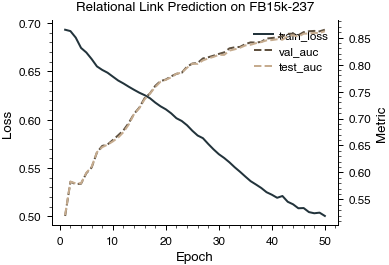

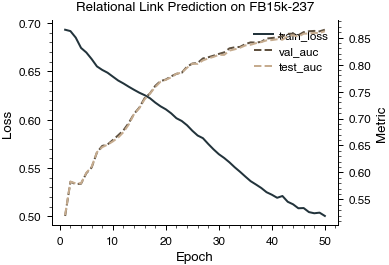

In [3]:
from graphnetz import plot_history

fig, ax = plot_history(history, title='Relational Link Prediction on FB15k-237')
fig

## Benchmark with automatic relational handling

The benchmark runner automatically detects relational datasets and uses
the relational decoder instead of the dot-product decoder.

In [4]:
from graphnetz import GAT, GCN, GraphSAGE, run_benchmark

report = run_benchmark(
    'knowledge',
    {'GCN': GCN, 'GAT': GAT, 'GraphSAGE': GraphSAGE},
    task'link_pred',
    seeds=(0, 1, 2, 3, 4, 5, 6, 7, 8, 9),
    epochs=30,
    verbose=True,
)
print(report.summary())

Benchmark:   0%|          | 0/60 [00:00<?, ?run/s]Downloading https://raw.githubusercontent.com/MichSchli/RelationPrediction/master/data/FB-Toutanova/entities.dict
Processing...
Done!
Benchmark:  50%|█████     | 30/60 [08:08<05:36, 11.20s/run]Downloading https://raw.githubusercontent.com/villmow/datasets_knowledge_embedding/master/WN18RR/original/train.txt
Processing...
Done!
Benchmark: 100%|██████████| 60/60 [13:58<00:00, 13.98s/run]


                       n_seeds      mean       std       sem    ci_low  \
task        model                                                        
fb15k_237   GAT             10  0.545135  0.012059  0.003813  0.536508   
            GCN             10  0.722612  0.010507  0.003323  0.715096   
            GraphSAGE       10  0.629969  0.053916  0.017050  0.591400   
wordnet18rr GAT             10  0.517106  0.009121  0.002884  0.510581   
            GCN             10  0.698861  0.014598  0.004616  0.688418   
            GraphSAGE       10  0.599410  0.019687  0.006226  0.585327   

                        ci_high  
task        model                
fb15k_237   GAT        0.553761  
            GCN        0.730128  
            GraphSAGE  0.668538  
wordnet18rr GAT        0.523631  
            GCN        0.709304  
            GraphSAGE  0.613494  


In [5]:
print(report.pairwise())

          task model_a    model_b  mean_diff         p_raw        p_holm  \
0    fb15k_237     GAT        GCN  -0.177477  3.765969e-11  1.129791e-10   
1    fb15k_237     GAT  GraphSAGE  -0.084834  1.126966e-03  1.408984e-03   
2    fb15k_237     GCN  GraphSAGE   0.092643  7.044921e-04  1.408984e-03   
3  wordnet18rr     GAT        GCN  -0.181755  1.562540e-10  4.687619e-10   
4  wordnet18rr     GAT  GraphSAGE  -0.082304  5.288273e-08  1.057655e-07   
5  wordnet18rr     GCN  GraphSAGE   0.099451  1.052181e-07  1.057655e-07   

   significant  
0         True  
1         True  
2         True  
3         True  
4         True  
5         True  


(<Figure size 864.6x271.2 with 1 Axes>, <Axes: >)

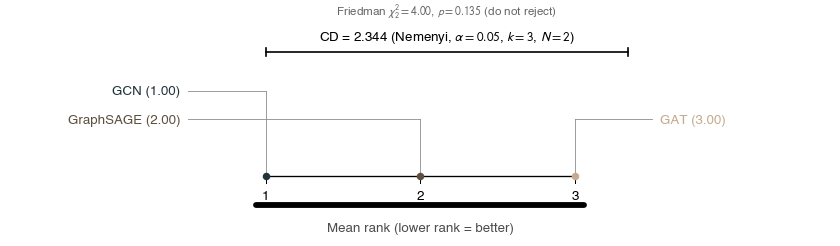

In [8]:
report.plot_critical_difference(alpha=0.05)

## Comparison: relational vs. homogeneous decoder

The relational decoder (DistMult) explicitly models relation types,
while the homogeneous decoder (dot-product) ignores them.

| Feature | Homogeneous LP | Relational LP |
|---|---|---|
| Decoder | ``z[h] @ z[t]`` | ``z[h] * r * z[t]`` |
| Parameters | ``|E| x d`` | ``|E| x d + |R| x d`` |
| FB15k-237 | treats all edges equally | models 237 relation types |
| Use case | social/citation networks | knowledge graphs |